# 💳 Banking Fraud & Transaction Risk Analysis

## 🔎 Phase 1 — Data Understanding

This notebook analyzes banking transaction data to identify fraud patterns, high-risk transactions, customer behavior, and merchant risk.

### 🎯 Business Objectives
- Monitor overall transaction activity.
- Measure fraud frequency and financial exposure.
- Identify high-risk transaction patterns.
- Analyze fraud by time, merchant, category, and location.
- Prepare the data for an interactive Fraud Risk Dashboard.

### 🛠️ Tools
Python • Pandas • NumPy • Matplotlib • Plotly • Streamlit

In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 📂 1. Load the Dataset

The training dataset contains historical transaction records that will be used for data understanding, cleaning, exploratory analysis, and dashboard development.

In [2]:
df = pd.read_csv("/content/fraudTrain.csv")

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0


## 📐 2. Dataset Structure

Before transforming the data, we inspect its size, columns, data types, and overall structure.

In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Number of Rows: 1296675
Number of Columns: 23

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


## 🧪 3. Initial Data Quality Check

At this stage, we inspect missing values, duplicated records, and basic data quality issues before applying any transformations.

In [4]:
quality_check = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Values": df.nunique()
})

quality_check

,Data Type,Missing Values,Missing %,Unique Values
Unnamed: 0,int64,0,0.00,1296675
trans_date_trans_time,object,0,0.00,1274791
cc_num,int64,0,0.00,983
merchant,object,0,0.00,693
category,object,0,0.00,14
amt,float64,0,0.00,52928
first,object,0,0.00,352
last,object,0,0.00,481
gender,object,0,0.00,2
street,object,0,0.00,983


In [7]:
print("Duplicated Rows:", df.duplicated().sum())

Duplicated Rows: 0


## 🚨 4. Fraud Target Distribution

Fraud detection datasets are typically highly imbalanced. Therefore, we first examine the distribution between legitimate and fraudulent transactions.

In [8]:
fraud_distribution = df["is_fraud"].value_counts()

fraud_distribution

,count
is_fraud,
0,1289169
1,7506


In [9]:
fraud_percentage = df["is_fraud"].value_counts(normalize=True).mul(100)

fraud_percentage

,proportion
is_fraud,
0,99.42
1,0.58


# 🧹 Phase 2 — Data Cleaning

The dataset is cleaned and prepared to ensure consistency, accuracy, and suitability for fraud analysis and dashboard development.

### Cleaning Steps
- Remove unnecessary columns.
- Validate missing and duplicated records.
- Correct data types.
- Convert date and time fields.
- Validate transaction identifiers.
- Check categorical values.
- Inspect numerical values and potential outliers.

## 🗑️ 1. Remove Unnecessary Columns

The `Unnamed: 0` column represents an exported index and does not provide analytical or business value.

In [10]:
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0


In [11]:
print("Number of Columns:", df.shape[1])

Number of Columns: 22


## 📅 2. Correct Date & Time Data Types

Transaction timestamps and customer birth dates are converted into proper datetime formats to support time-based and customer-level analysis.

In [12]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"]
)

df["dob"] = pd.to_datetime(
    df["dob"]
)

In [13]:
df[["trans_date_trans_time", "dob"]].dtypes

,0
trans_date_trans_time,datetime64[ns]
dob,datetime64[ns]


In [14]:
df["is_fraud"] = df["is_fraud"].astype(int)

In [15]:
df["is_fraud"].value_counts()

,count
is_fraud,
0,1289169
1,7506


## ✅ 3. Cleaning Validation

After the initial cleaning steps, the dataset is validated again to confirm its structure and data quality.

In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicated Rows:", df.duplicated().sum())

df.info()

Rows: 1296675
Columns: 22
Missing Values: 0
Duplicated Rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    129

# ⚙️ Phase 3 — Feature Engineering

New analytical features are created from the existing transaction data to support time-based fraud analysis, customer profiling, geographic risk assessment, and dashboard development.

## 🕒 1. Time-Based Features

Transaction timestamps are decomposed into useful time features to identify fraud patterns across hours, days, and months.

In [17]:
df["transaction_date"] = df["trans_date_trans_time"].dt.date
df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.day_name()
df["month"] = df["trans_date_trans_time"].dt.month_name()

df["is_weekend"] = df["trans_date_trans_time"].dt.dayofweek.isin([5, 6]).astype(int)

## 🌙 2. Transaction Period

Transactions are grouped into time periods to simplify behavioral and fraud-risk analysis.

In [18]:
def get_transaction_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["transaction_period"] = df["transaction_hour"].apply(get_transaction_period)

## 👤 3. Customer Age

Customer age is calculated at the time of each transaction to support demographic risk analysis.

In [19]:
df["customer_age"] = (
    df["trans_date_trans_time"].dt.year - df["dob"].dt.year
)

In [20]:
df["customer_age"].describe()

,customer_age
count,"1,296,675.00"
mean,46.03
std,17.38
min,14.00
25%,33.00
50%,44.00
75%,57.00
max,96.00


## 📍 4. Customer–Merchant Distance

The geographic distance between the customer's location and the merchant's location is calculated to identify unusual transaction behavior.

In [21]:
from numpy import radians, sin, cos, sqrt, arctan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2

    c = 2 * arctan2(sqrt(a), sqrt(1 - a))

    return R * c

In [22]:
df["distance_km"] = haversine_distance(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

In [23]:
df[[
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "distance_km"
]].head()

,lat,long,merch_lat,merch_long,distance_km
0,36.08,-81.18,36.01,-82.05,78.60
1,48.89,-118.21,49.16,-118.19,30.21
2,42.18,-112.26,43.15,-112.15,108.21
3,46.23,-112.11,47.03,-112.56,95.67
4,38.42,-79.46,38.67,-78.63,77.56


## ✅ 5. Feature Engineering Validation

The newly engineered features are reviewed before proceeding to exploratory data analysis.

In [24]:
new_features = [
    "transaction_date",
    "transaction_hour",
    "day_of_week",
    "month",
    "is_weekend",
    "transaction_period",
    "customer_age",
    "distance_km"
]

df[new_features].head()

,transaction_date,transaction_hour,day_of_week,month,is_weekend,transaction_period,customer_age,distance_km
0,2019-01-01,0,Tuesday,January,0,Night,31,78.60
1,2019-01-01,0,Tuesday,January,0,Night,41,30.21
2,2019-01-01,0,Tuesday,January,0,Night,57,108.21
3,2019-01-01,0,Tuesday,January,0,Night,52,95.67
4,2019-01-01,0,Tuesday,January,0,Night,33,77.56


In [25]:
print("Total Columns After Feature Engineering:", df.shape[1])

Total Columns After Feature Engineering: 30


# 📊 Phase 4 — Exploratory Data Analysis

The objective of this phase is to understand transaction behavior, fraud patterns, financial exposure, and high-risk segments before building the interactive dashboard.

### Key Business Questions
- How many transactions were processed?
- What is the fraud rate?
- What is the total fraudulent amount?
- Which categories are more exposed to fraud?
- What are the highest-risk hours and days?
- Which merchants and locations show higher fraud activity?
- How do transaction amount and geographic distance relate to fraud?

## 💼 1. Executive Fraud KPIs

The first step is to calculate the core business metrics that will later appear in the Executive Overview dashboard.

In [26]:
total_transactions = len(df)

total_amount = df["amt"].sum()

fraud_transactions = df["is_fraud"].sum()

fraud_rate = (
    fraud_transactions / total_transactions
) * 100

fraud_amount = df.loc[
    df["is_fraud"] == 1,
    "amt"
].sum()

average_transaction_value = df["amt"].mean()

In [27]:
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Transaction Amount: ${total_amount:,.2f}")
print(f"Fraudulent Transactions: {fraud_transactions:,}")
print(f"Fraud Rate: {fraud_rate:.2f}%")
print(f"Fraudulent Amount: ${fraud_amount:,.2f}")
print(f"Average Transaction Value: ${average_transaction_value:,.2f}")

Total Transactions: 1,296,675
Total Transaction Amount: $91,222,428.90
Fraudulent Transactions: 7,506
Fraud Rate: 0.58%
Fraudulent Amount: $3,988,088.61
Average Transaction Value: $70.35


## 🚨 2. Fraud vs Legitimate Transactions

This analysis compares legitimate and fraudulent transactions to understand the overall class imbalance and fraud exposure.

In [28]:
fraud_summary = (
    df.groupby("is_fraud")
      .agg(
          transactions=("trans_num", "count"),
          total_amount=("amt", "sum"),
          average_amount=("amt", "mean")
      )
)

fraud_summary

,transactions,total_amount,average_amount
is_fraud,,,
0,1289169,"87,234,340.29",67.67
1,7506,"3,988,088.61",531.32


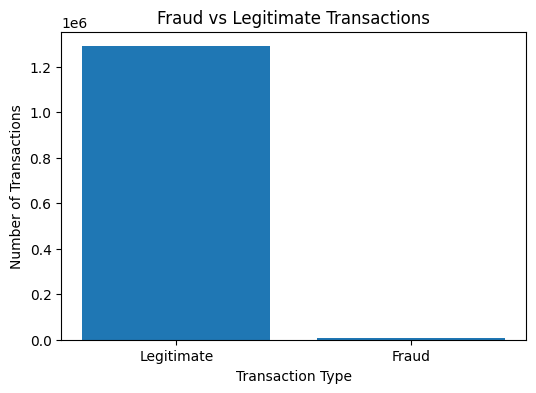

In [29]:
import matplotlib.pyplot as plt

fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Legitimate", "Fraud"],
    fraud_counts.values
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

## 🛍️ 3. Fraud Risk by Transaction Category

Transaction categories are analyzed to identify the segments with the highest fraud frequency and fraud rate.

In [30]:
category_analysis = (
    df.groupby("category")
      .agg(
          total_transactions=("trans_num", "count"),
          fraud_transactions=("is_fraud", "sum"),
          total_amount=("amt", "sum"),
          fraud_amount=(
              "amt",
              lambda x: x[df.loc[x.index, "is_fraud"] == 1].sum()
          )
      )
)

category_analysis["fraud_rate"] = (
    category_analysis["fraud_transactions"]
    / category_analysis["total_transactions"]
    * 100
)

category_analysis.sort_values(
    "fraud_rate",
    ascending=False
).head(10)

,total_transactions,fraud_transactions,total_amount,fraud_amount,fraud_rate
category,,,,,
shopping_net,97543,1713,"8,625,149.68","1,711,723.71",1.76
misc_net,63287,915,"5,117,709.26","729,266.76",1.45
grocery_pos,123638,1743,"14,460,822.38","543,797.90",1.41
shopping_pos,116672,843,"9,307,993.61","739,245.09",0.72
gas_transport,131659,618,"8,351,732.29","7,594.11",0.47
misc_pos,79655,250,"5,009,582.50","54,571.02",0.31
grocery_net,45452,134,"2,439,412.68","1,629.82",0.29
travel,40507,116,"4,516,721.68","1,051.49",0.29
entertainment,94014,233,"6,036,678.56","117,323.79",0.25


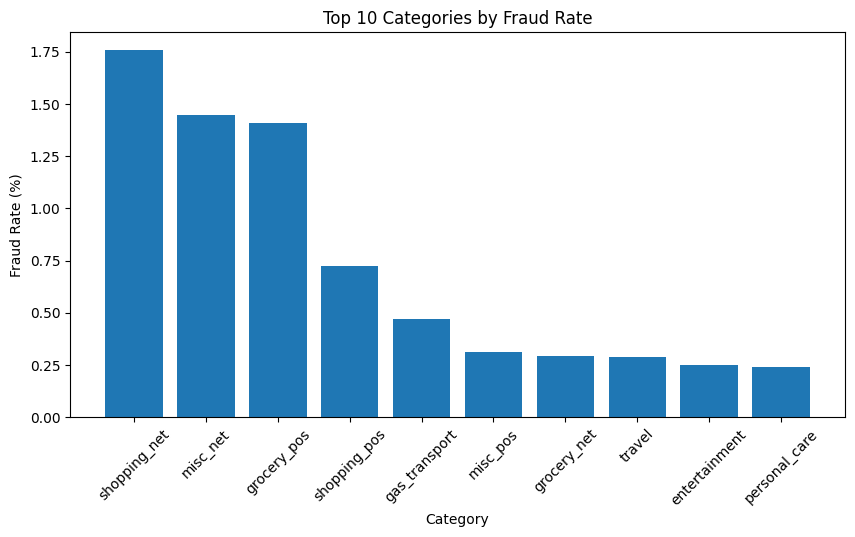

In [31]:
top_categories = (
    category_analysis
    .sort_values("fraud_rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_categories.index,
    top_categories["fraud_rate"]
)

plt.title("Top 10 Categories by Fraud Rate")
plt.xlabel("Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

## 🕒 4. Fraud Risk by Hour

Fraud activity is analyzed across the 24-hour cycle to identify high-risk transaction periods.

In [32]:
hour_analysis = (
    df.groupby("transaction_hour")
      .agg(
          total_transactions=("trans_num", "count"),
          fraud_transactions=("is_fraud", "sum")
      )
)

hour_analysis["fraud_rate"] = (
    hour_analysis["fraud_transactions"]
    / hour_analysis["total_transactions"]
    * 100
)

hour_analysis

,total_transactions,fraud_transactions,fraud_rate
transaction_hour,,,
0,42502,635,1.49
1,42869,658,1.53
2,42656,625,1.47
3,42769,609,1.42
4,41863,46,0.11
5,42171,60,0.14
6,42300,40,0.09
7,42203,56,0.13
8,42505,49,0.12


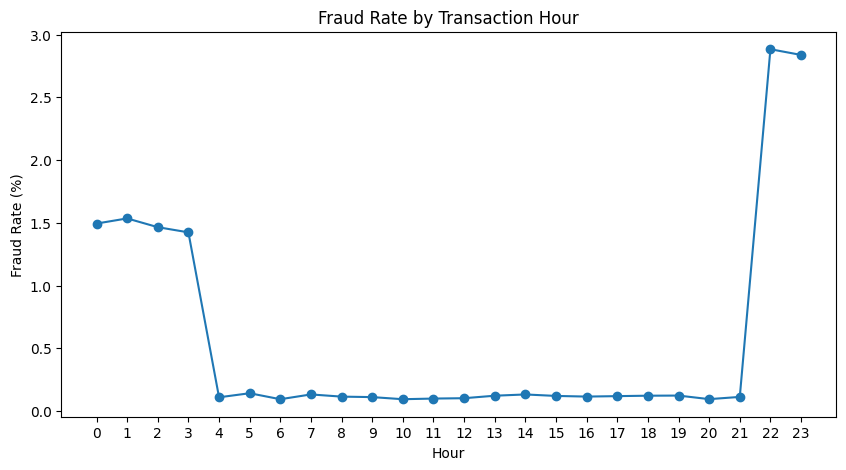

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    hour_analysis.index,
    hour_analysis["fraud_rate"],
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))

plt.show()

## 📅 5. Fraud Risk by Day of Week

Fraud behavior is analyzed across weekdays to detect recurring temporal patterns.

In [34]:
day_analysis = (
    df.groupby("day_of_week")
      .agg(
          total_transactions=("trans_num", "count"),
          fraud_transactions=("is_fraud", "sum")
      )
)

day_analysis["fraud_rate"] = (
    day_analysis["fraud_transactions"]
    / day_analysis["total_transactions"]
    * 100
)

day_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

,total_transactions,fraud_transactions,fraud_rate
day_of_week,,,
Friday,152272,1079,0.71
Thursday,147285,1008,0.68
Wednesday,131073,859,0.66
Saturday,200957,1227,0.61
Tuesday,160227,935,0.58
Sunday,250579,1216,0.49
Monday,254282,1182,0.46


## 🏪 6. Merchant Fraud Risk

Merchant-level analysis helps identify merchants with unusually high fraud activity and financial exposure.

In [35]:
merchant_analysis = (
    df.groupby("merchant")
      .agg(
          total_transactions=("trans_num", "count"),
          fraud_transactions=("is_fraud", "sum"),
          total_amount=("amt", "sum")
      )
)

merchant_analysis["fraud_rate"] = (
    merchant_analysis["fraud_transactions"]
    / merchant_analysis["total_transactions"]
    * 100
)

merchant_analysis.sort_values(
    "fraud_transactions",
    ascending=False
).head(10)

,total_transactions,fraud_transactions,total_amount,fraud_rate
merchant,,,,
fraud_Rau and Sons,2490,49,"298,354.77",1.97
fraud_Kozey-Boehm,1866,48,"183,312.29",2.57
fraud_Cormier LLC,3649,48,"265,129.92",1.32
fraud_Vandervort-Funk,2474,47,"292,542.99",1.90
fraud_Doyle Ltd,2558,47,"300,971.37",1.84
fraud_Kilback LLC,4403,47,"391,078.15",1.07
fraud_Kuhn LLC,3510,44,"282,207.15",1.25
fraud_Padberg-Welch,2424,44,"279,775.98",1.82
fraud_Terry-Huel,1996,43,"186,191.02",2.15


## 💰 7. Transaction Amount and Fraud

Transaction values are compared between legitimate and fraudulent transactions to determine whether fraud is associated with higher monetary amounts.

In [36]:
amount_analysis = (
    df.groupby("is_fraud")["amt"]
      .agg(["count", "mean", "median", "min", "max"])
)

amount_analysis

,count,mean,median,min,max
is_fraud,,,,,
0,1289169,67.67,47.28,1.00,"28,948.90"
1,7506,531.32,396.50,1.06,"1,376.04"


In [37]:
fraud_only = df[df["is_fraud"] == 1]

fraud_only["amt"].describe()

,amt
count,"7,506.00"
mean,531.32
std,390.56
min,1.06
25%,245.66
50%,396.50
75%,900.88
max,"1,376.04"


## 📍 8. Geographic Distance and Fraud Risk

Customer-to-merchant distance is analyzed to determine whether geographically unusual transactions are associated with higher fraud risk.

In [38]:
distance_analysis = (
    df.groupby("is_fraud")["distance_km"]
      .agg(["mean", "median", "min", "max"])
)

distance_analysis

,mean,median,min,max
is_fraud,,,,
0,76.11,78.23,0.02,152.12
1,76.27,77.93,0.74,144.52


## 👤 9. Customer Age and Fraud

Customer age is analyzed to identify whether certain age groups experience higher fraud exposure.

In [39]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        "Under 25",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
)

In [40]:
age_analysis = (
    df.groupby("age_group", observed=False)
      .agg(
          total_transactions=("trans_num", "count"),
          fraud_transactions=("is_fraud", "sum")
      )
)

age_analysis["fraud_rate"] = (
    age_analysis["fraud_transactions"]
    / age_analysis["total_transactions"]
    * 100
)

age_analysis

,total_transactions,fraud_transactions,fraud_rate
age_group,,,
Under 25,131162,825,0.63
25-34,297451,1398,0.47
35-44,265320,1150,0.43
45-54,253342,1487,0.59
55-64,164087,1240,0.76
65+,185313,1406,0.76


# 🛡️ Phase 5 — Transaction Risk Scoring

A rule-based risk scoring framework is developed to classify transactions into Low, Medium, and High Risk levels based on fraud patterns identified during exploratory analysis.

### Risk Factors
- High transaction amount
- High-risk transaction hours
- High-risk transaction categories
- High-risk merchants
- Customer age risk
- Geographic distance

In [41]:
fraud_amount_threshold = df[df["is_fraud"] == 1]["amt"].median()

fraud_amount_threshold

396.505

In [42]:
high_risk_categories = [
    "shopping_net",
    "misc_net",
    "grocery_pos"
]

high_risk_hours = [22, 23, 0, 1, 2, 3]

high_risk_age_groups = [
    "55-64",
    "65+"
]

In [43]:
def calculate_risk_score(row):

    score = 0

    # High transaction amount
    if row["amt"] >= fraud_amount_threshold:
        score += 30

    # High-risk time
    if row["transaction_hour"] in high_risk_hours:
        score += 25

    # High-risk category
    if row["category"] in high_risk_categories:
        score += 25

    # Higher-risk age group
    if str(row["age_group"]) in high_risk_age_groups:
        score += 10

    # Large customer-merchant distance
    if row["distance_km"] > 100:
        score += 10

    return score

In [44]:
df["risk_score"] = df.apply(
    calculate_risk_score,
    axis=1
)

In [45]:
def classify_risk(score):

    if score >= 60:
        return "High Risk"

    elif score >= 30:
        return "Medium Risk"

    else:
        return "Low Risk"

In [46]:
df["risk_level"] = df["risk_score"].apply(
    classify_risk
)

In [47]:
df[
    [
        "trans_num",
        "amt",
        "transaction_hour",
        "category",
        "age_group",
        "distance_km",
        "risk_score",
        "risk_level",
        "is_fraud"
    ]
].head(10)

,trans_num,amt,transaction_hour,category,age_group,distance_km,risk_score,risk_level,is_fraud
0,0b242abb623afc578575680df30655b9,4.97,0,misc_net,25-34,78.60,50,Medium Risk,0
1,1f76529f8574734946361c461b024d99,107.23,0,grocery_pos,35-44,30.21,50,Medium Risk,0
2,a1a22d70485983eac12b5b88dad1cf95,220.11,0,entertainment,55-64,108.21,45,Medium Risk,0
3,6b849c168bdad6f867558c3793159a81,45.00,0,gas_transport,45-54,95.67,25,Low Risk,0
4,a41d7549acf90789359a9aa5346dcb46,41.96,0,misc_pos,25-34,77.56,25,Low Risk,0
5,189a841a0a8ba03058526bcfe566aab5,94.63,0,gas_transport,55-64,85.92,35,Medium Risk,0
6,83ec1cc84142af6e2acf10c44949e720,44.54,0,grocery_net,25-34,118.12,35,Medium Risk,0
7,6d294ed2cc447d2c71c7171a3d54967c,71.65,0,gas_transport,65+,12.77,35,Medium Risk,0
8,fc28024ce480f8ef21a32d64c93a29f5,4.27,0,misc_pos,65+,25.27,35,Medium Risk,0
9,3b9014ea8fb80bd65de0b1463b00b00e,198.39,0,grocery_pos,35-44,74.08,50,Medium Risk,0


In [48]:
df["risk_level"].value_counts()

,count
risk_level,
Low Risk,1009954
Medium Risk,241202
High Risk,45519


## ✅ Risk Scoring Validation

The rule-based risk framework is validated by comparing fraud rates across Low, Medium, and High Risk transactions.

In [49]:
risk_validation = (
    df.groupby("risk_level")
      .agg(
          total_transactions=("trans_num", "count"),
          fraud_transactions=("is_fraud", "sum")
      )
)

risk_validation["fraud_rate"] = (
    risk_validation["fraud_transactions"]
    / risk_validation["total_transactions"]
    * 100
)

risk_validation

,total_transactions,fraud_transactions,fraud_rate
risk_level,,,
High Risk,45519,3727,8.19
Low Risk,1009954,1365,0.14
Medium Risk,241202,2414,1.00


In [50]:
risk_order = ["Low Risk", "Medium Risk", "High Risk"]

risk_validation = risk_validation.reindex(risk_order)

risk_validation

,total_transactions,fraud_transactions,fraud_rate
risk_level,,,
Low Risk,1009954,1365,0.14
Medium Risk,241202,2414,1.00
High Risk,45519,3727,8.19


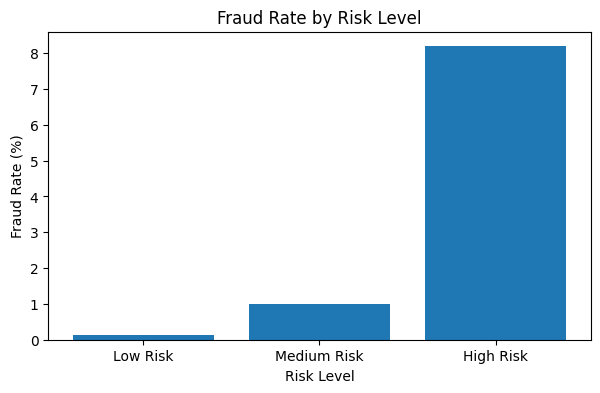

In [51]:
plt.figure(figsize=(7, 4))

plt.bar(
    risk_validation.index,
    risk_validation["fraud_rate"]
)

plt.title("Fraud Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Fraud Rate (%)")

plt.show()

## 📌 Risk Scoring Insight

The rule-based risk framework demonstrates strong transaction prioritization.

- Low Risk transactions recorded a fraud rate of 0.14%.
- Medium Risk transactions recorded a fraud rate of 1.00%.
- High Risk transactions recorded a fraud rate of 8.19%.
- High Risk transactions represent a relatively small portion of total activity while capturing a significant share of fraudulent transactions.

This indicates that the framework can help fraud investigation teams prioritize transactions requiring immediate review.

> The framework will next be validated on unseen test data to assess its ability to generalize.

# 🧪 Phase 6 — Out-of-Sample Validation

The risk scoring framework is now evaluated on unseen test transactions.

The same preprocessing logic, engineered features, risk factors, scoring weights, and classification thresholds are applied without modification to assess how well the framework generalizes to new transaction data.

In [52]:
test_df = pd.read_csv("/content/fraudTest.csv")

print("Rows:", test_df.shape[0])
print("Columns:", test_df.shape[1])

test_df.head()

Rows: 555719
Columns: 23


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.97,-80.94,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.99,-81.20,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.32,-110.44,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.45,-109.96,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.67,-73.54,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.50,-74.20,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.57,-80.82,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.81,-80.88,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.25,-85.02,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.96,-85.88,0


In [53]:
test_df.drop(columns=["Unnamed: 0"], inplace=True)

test_df["trans_date_trans_time"] = pd.to_datetime(
    test_df["trans_date_trans_time"]
)

test_df["dob"] = pd.to_datetime(
    test_df["dob"]
)

test_df["is_fraud"] = test_df["is_fraud"].astype(int)

## ⚙️ Apply the Same Feature Engineering

The same features created during model development are reproduced for the unseen test dataset to ensure a consistent validation process.

In [54]:
test_df["transaction_date"] = test_df["trans_date_trans_time"].dt.date
test_df["transaction_hour"] = test_df["trans_date_trans_time"].dt.hour
test_df["day_of_week"] = test_df["trans_date_trans_time"].dt.day_name()
test_df["month"] = test_df["trans_date_trans_time"].dt.month_name()

test_df["is_weekend"] = (
    test_df["trans_date_trans_time"]
    .dt.dayofweek
    .isin([5, 6])
    .astype(int)
)

test_df["transaction_period"] = (
    test_df["transaction_hour"]
    .apply(get_transaction_period)
)

test_df["customer_age"] = (
    test_df["trans_date_trans_time"].dt.year
    - test_df["dob"].dt.year
)

In [55]:
test_df["distance_km"] = haversine_distance(
    test_df["lat"],
    test_df["long"],
    test_df["merch_lat"],
    test_df["merch_long"]
)

In [56]:
test_df["age_group"] = pd.cut(
    test_df["customer_age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        "Under 25",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
)

In [57]:
test_df["risk_score"] = test_df.apply(
    calculate_risk_score,
    axis=1
)

test_df["risk_level"] = test_df["risk_score"].apply(
    classify_risk
)

## ✅ Test Risk Validation

Fraud rates are compared across the three risk levels to determine whether the risk framework maintains its prioritization ability on unseen data.

In [58]:
test_risk_validation = (
    test_df.groupby("risk_level")
    .agg(
        total_transactions=("trans_num", "count"),
        fraud_transactions=("is_fraud", "sum")
    )
)

test_risk_validation["fraud_rate"] = (
    test_risk_validation["fraud_transactions"]
    / test_risk_validation["total_transactions"]
    * 100
)

risk_order = ["Low Risk", "Medium Risk", "High Risk"]

test_risk_validation = test_risk_validation.reindex(risk_order)

test_risk_validation

,total_transactions,fraud_transactions,fraud_rate
risk_level,,,
Low Risk,432558,402,0.09
Medium Risk,103889,694,0.67
High Risk,19272,1049,5.44


## 📌 Out-of-Sample Validation Insight

The risk scoring framework maintained strong prioritization performance on unseen transaction data.

- Low Risk fraud rate: **0.09%**
- Medium Risk fraud rate: **0.67%**
- High Risk fraud rate: **5.44%**

High-Risk transactions represented only about **3.5% of unseen transactions**, while capturing approximately **49% of all fraudulent transactions**.

This demonstrates that the rule-based framework generalizes beyond the development dataset and can effectively prioritize transactions for investigation.

# 🗂️ Phase 7 — Dashboard Data Preparation

The validated training and test datasets are consolidated into a dashboard-ready transaction dataset.

The objective is to create a clean analytical layer that can be loaded directly by the Streamlit application without repeating the preprocessing and feature engineering pipeline.

In [59]:
df["dataset_split"] = "Train"
test_df["dataset_split"] = "Test"

In [60]:
print(df["dataset_split"].value_counts())
print(test_df["dataset_split"].value_counts())

dataset_split
Train    1296675
Name: count, dtype: int64
dataset_split
Test    555719
Name: count, dtype: int64


## 🔗 1. Consolidate Transaction History

The processed training and unseen test transactions are combined into a single historical analytical dataset while preserving their original dataset source.

In [61]:
dashboard_df = pd.concat(
    [df, test_df],
    ignore_index=True
)

In [62]:
print("Dashboard Rows:", dashboard_df.shape[0])
print("Dashboard Columns:", dashboard_df.shape[1])

dashboard_df.head()

Dashboard Rows: 1852394
Dashboard Columns: 34


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,transaction_date,transaction_hour,day_of_week,month,is_weekend,transaction_period,customer_age,distance_km,age_group,risk_score,risk_level,dataset_split
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0,2019-01-01,0,Tuesday,January,0,Night,31,78.60,25-34,50,Medium Risk,Train
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0,2019-01-01,0,Tuesday,January,0,Night,41,30.21,35-44,50,Medium Risk,Train
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0,2019-01-01,0,Tuesday,January,0,Night,57,108.21,55-64,45,Medium Risk,Train
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0,2019-01-01,0,Tuesday,January,0,Night,52,95.67,45-54,25,Low Risk,Train
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0,2019-01-01,0,Tuesday,January,0,Night,33,77.56,25-34,25,Low Risk,Train


In [63]:
dashboard_df["dataset_split"].value_counts()

,count
dataset_split,
Train,1296675
Test,555719


In [64]:
print("Missing Values:", dashboard_df.isnull().sum().sum())
print("Duplicated Transactions:", dashboard_df["trans_num"].duplicated().sum())

Missing Values: 0
Duplicated Transactions: 0


## 🎯 2. Select Dashboard Features

Only business-relevant and analytical features are retained for the interactive dashboard to simplify the application layer and improve usability.

In [65]:
dashboard_columns = [
    "trans_num",
    "trans_date_trans_time",
    "transaction_date",
    "transaction_hour",
    "day_of_week",
    "month",
    "transaction_period",

    "cc_num",
    "first",
    "last",
    "gender",
    "customer_age",
    "age_group",

    "merchant",
    "category",
    "amt",

    "city",
    "state",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "distance_km",

    "is_weekend",
    "is_fraud",
    "risk_score",
    "risk_level",
    "dataset_split"
]

dashboard_df = dashboard_df[dashboard_columns].copy()

In [66]:
print("Final Dashboard Columns:", dashboard_df.shape[1])

dashboard_df.head()

Final Dashboard Columns: 28


,trans_num,trans_date_trans_time,transaction_date,transaction_hour,day_of_week,month,transaction_period,cc_num,first,last,gender,customer_age,age_group,merchant,category,amt,city,state,lat,long,merch_lat,merch_long,distance_km,is_weekend,is_fraud,risk_score,risk_level,dataset_split
0,0b242abb623afc578575680df30655b9,2019-01-01 00:00:18,2019-01-01,0,Tuesday,January,Night,2703186189652095,Jennifer,Banks,F,31,25-34,"fraud_Rippin, Kub and Mann",misc_net,4.97,Moravian Falls,NC,36.08,-81.18,36.01,-82.05,78.60,0,0,50,Medium Risk,Train
1,1f76529f8574734946361c461b024d99,2019-01-01 00:00:44,2019-01-01,0,Tuesday,January,Night,630423337322,Stephanie,Gill,F,41,35-44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.89,-118.21,49.16,-118.19,30.21,0,0,50,Medium Risk,Train
2,a1a22d70485983eac12b5b88dad1cf95,2019-01-01 00:00:51,2019-01-01,0,Tuesday,January,Night,38859492057661,Edward,Sanchez,M,57,55-64,fraud_Lind-Buckridge,entertainment,220.11,Malad City,ID,42.18,-112.26,43.15,-112.15,108.21,0,0,45,Medium Risk,Train
3,6b849c168bdad6f867558c3793159a81,2019-01-01 00:01:16,2019-01-01,0,Tuesday,January,Night,3534093764340240,Jeremy,White,M,52,45-54,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Boulder,MT,46.23,-112.11,47.03,-112.56,95.67,0,0,25,Low Risk,Train
4,a41d7549acf90789359a9aa5346dcb46,2019-01-01 00:03:06,2019-01-01,0,Tuesday,January,Night,375534208663984,Tyler,Garcia,M,33,25-34,fraud_Keeling-Crist,misc_pos,41.96,Doe Hill,VA,38.42,-79.46,38.67,-78.63,77.56,0,0,25,Low Risk,Train


## 👤 3. Create Customer Display Name

Customer first and last names are combined into a single display field for investigation and dashboard filtering.

In [67]:
dashboard_df["customer_name"] = (
    dashboard_df["first"].str.strip()
    + " "
    + dashboard_df["last"].str.strip()
)

In [68]:
dashboard_df[
    ["cc_num", "customer_name", "merchant", "amt", "risk_level"]
].head()

,cc_num,customer_name,merchant,amt,risk_level
0,2703186189652095,Jennifer Banks,"fraud_Rippin, Kub and Mann",4.97,Medium Risk
1,630423337322,Stephanie Gill,"fraud_Heller, Gutmann and Zieme",107.23,Medium Risk
2,38859492057661,Edward Sanchez,fraud_Lind-Buckridge,220.11,Medium Risk
3,3534093764340240,Jeremy White,"fraud_Kutch, Hermiston and Farrell",45.00,Low Risk
4,375534208663984,Tyler Garcia,fraud_Keeling-Crist,41.96,Low Risk


## 🚨 4. Investigation Priority

A review-priority field is created from the validated risk level to support fraud investigation workflows.

This field represents analytical investigation priority, not an actual banking transaction status.

In [69]:
priority_map = {
    "High Risk": "Immediate Review",
    "Medium Risk": "Monitor",
    "Low Risk": "Standard"
}

dashboard_df["review_priority"] = (
    dashboard_df["risk_level"].map(priority_map)
)

In [70]:
dashboard_df[
    [
        "trans_num",
        "amt",
        "risk_score",
        "risk_level",
        "review_priority",
        "is_fraud"
    ]
].head(10)

,trans_num,amt,risk_score,risk_level,review_priority,is_fraud
0,0b242abb623afc578575680df30655b9,4.97,50,Medium Risk,Monitor,0
1,1f76529f8574734946361c461b024d99,107.23,50,Medium Risk,Monitor,0
2,a1a22d70485983eac12b5b88dad1cf95,220.11,45,Medium Risk,Monitor,0
3,6b849c168bdad6f867558c3793159a81,45.00,25,Low Risk,Standard,0
4,a41d7549acf90789359a9aa5346dcb46,41.96,25,Low Risk,Standard,0
5,189a841a0a8ba03058526bcfe566aab5,94.63,35,Medium Risk,Monitor,0
6,83ec1cc84142af6e2acf10c44949e720,44.54,35,Medium Risk,Monitor,0
7,6d294ed2cc447d2c71c7171a3d54967c,71.65,35,Medium Risk,Monitor,0
8,fc28024ce480f8ef21a32d64c93a29f5,4.27,35,Medium Risk,Monitor,0
9,3b9014ea8fb80bd65de0b1463b00b00e,198.39,50,Medium Risk,Monitor,0


## ✅ 5. Dashboard Dataset Validation

The final analytical dataset is validated before being exported for use by the Streamlit application.

In [71]:
print("Total Transactions:", f"{len(dashboard_df):,}")
print("Total Columns:", dashboard_df.shape[1])

print(
    "Fraud Transactions:",
    f"{dashboard_df['is_fraud'].sum():,}"
)

print(
    "High Risk Transactions:",
    f"{(dashboard_df['risk_level'] == 'High Risk').sum():,}"
)

print(
    "Missing Values:",
    dashboard_df.isnull().sum().sum()
)

print(
    "Duplicate Transaction IDs:",
    dashboard_df["trans_num"].duplicated().sum()
)

Total Transactions: 1,852,394
Total Columns: 30
Fraud Transactions: 9,651
High Risk Transactions: 64,791
Missing Values: 0
Duplicate Transaction IDs: 0


# ⚡ Phase 8 — Optimized Dashboard Data Layer

The final transaction dataset is optimized for efficient storage and faster loading within the Streamlit application.

The analytical layer preserves transaction-level detail while reducing unnecessary memory usage and preparing the data for interactive dashboard filtering and monitoring.

## 🧠 1. Optimize Data Types

Selected columns are converted into more memory-efficient data types to improve dashboard performance without changing their analytical meaning.

In [72]:
# Optimize integer columns
dashboard_df["transaction_hour"] = dashboard_df["transaction_hour"].astype("int8")
dashboard_df["is_weekend"] = dashboard_df["is_weekend"].astype("int8")
dashboard_df["is_fraud"] = dashboard_df["is_fraud"].astype("int8")
dashboard_df["risk_score"] = dashboard_df["risk_score"].astype("int8")

# Optimize categorical columns
category_columns = [
    "gender",
    "day_of_week",
    "month",
    "transaction_period",
    "age_group",
    "category",
    "state",
    "risk_level",
    "review_priority",
    "dataset_split"
]

for col in category_columns:
    dashboard_df[col] = dashboard_df[col].astype("category")

In [73]:
memory_mb = dashboard_df.memory_usage(deep=True).sum() / 1024**2

print(f"Dashboard Memory Usage: {memory_mb:,.2f} MB")

Dashboard Memory Usage: 892.43 MB


## 📅 2. Validate Dashboard Time Coverage

The complete transaction history is reviewed to confirm the final analytical time range available to dashboard users.

In [74]:
print(
    "Start Date:",
    dashboard_df["trans_date_trans_time"].min()
)

print(
    "End Date:",
    dashboard_df["trans_date_trans_time"].max()
)

Start Date: 2019-01-01 00:00:18
End Date: 2020-12-31 23:59:34


## 💼 3. Final Dashboard KPIs

Core metrics are recalculated across the complete consolidated transaction history to establish the official dashboard-level KPIs.

In [75]:
final_total_transactions = len(dashboard_df)

final_total_amount = dashboard_df["amt"].sum()

final_fraud_transactions = dashboard_df["is_fraud"].sum()

final_fraud_rate = (
    final_fraud_transactions
    / final_total_transactions
    * 100
)

final_fraud_amount = dashboard_df.loc[
    dashboard_df["is_fraud"] == 1,
    "amt"
].sum()

final_average_transaction = dashboard_df["amt"].mean()

final_high_risk = (
    dashboard_df["risk_level"] == "High Risk"
).sum()

final_average_risk_score = dashboard_df["risk_score"].mean()

In [76]:
print(f"Total Transactions: {final_total_transactions:,}")
print(f"Total Transaction Amount: ${final_total_amount:,.2f}")
print(f"Fraudulent Transactions: {final_fraud_transactions:,}")
print(f"Fraud Rate: {final_fraud_rate:.2f}%")
print(f"Fraudulent Amount: ${final_fraud_amount:,.2f}")
print(f"Average Transaction Value: ${final_average_transaction:,.2f}")
print(f"High-Risk Transactions: {final_high_risk:,}")
print(f"Average Risk Score: {final_average_risk_score:.2f}")

Total Transactions: 1,852,394
Total Transaction Amount: $129,785,332.01
Fraudulent Transactions: 9,651
Fraud Rate: 0.52%
Fraudulent Amount: $5,121,413.29
Average Transaction Value: $70.06
High-Risk Transactions: 64,791
Average Risk Score: 16.90


## 💾 4. Export Dashboard-Ready Dataset

The optimized transaction-level analytical dataset is exported in Parquet format for efficient use within the Streamlit application.

In [77]:
dashboard_df.to_parquet(
    "/content/banking_fraud_dashboard.parquet",
    index=False
)

print("Dashboard dataset exported successfully.")

Dashboard dataset exported successfully.


In [79]:
import os

file_size = os.path.getsize(
    "/content/banking_fraud_dashboard.parquet"
) / 1024**2

print(f"File Size: {file_size:,.2f} MB")


File Size: 142.13 MB


# ⚡ Phase 9 — Streamlit Data Layer

To deliver a fast and responsive web dashboard, lightweight analytical tables are created from the full transaction dataset.

These tables will power the dashboard KPIs, charts, filters, and fraud-monitoring components without repeatedly processing the complete transaction history.

In [80]:
daily_summary = (
    dashboard_df
    .groupby("transaction_date", observed=False)
    .agg(
        total_transactions=("trans_num", "count"),
        total_amount=("amt", "sum"),
        fraud_transactions=("is_fraud", "sum"),
        fraud_amount=(
            "amt",
            lambda x: x[dashboard_df.loc[x.index, "is_fraud"] == 1].sum()
        ),
        average_transaction_value=("amt", "mean"),
        average_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

daily_summary["fraud_rate"] = (
    daily_summary["fraud_transactions"]
    / daily_summary["total_transactions"]
    * 100
)

daily_summary.head()

,transaction_date,total_transactions,total_amount,fraud_transactions,fraud_amount,average_transaction_value,average_risk_score,fraud_rate
0,2019-01-01,2414,"156,487.09",0,0.00,64.82,16.51,0.00
1,2019-01-02,1118,"70,723.58",7,"2,540.36",63.26,17.11,0.63
2,2019-01-03,1236,"86,516.49",12,"6,804.78",70.00,17.35,0.97
3,2019-01-04,1474,"112,436.39",13,"7,521.76",76.28,16.76,0.88
4,2019-01-05,1409,"97,496.13",13,"7,155.78",69.20,17.16,0.92


In [81]:
category_summary = (
    dashboard_df
    .groupby("category", observed=False)
    .agg(
        total_transactions=("trans_num", "count"),
        total_amount=("amt", "sum"),
        fraud_transactions=("is_fraud", "sum"),
        average_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

category_summary["fraud_rate"] = (
    category_summary["fraud_transactions"]
    / category_summary["total_transactions"]
    * 100
)

category_summary.head()

,category,total_transactions,total_amount,fraud_transactions,average_risk_score,fraud_rate
0,entertainment,134118,"8,602,726.58",292,10.20,0.22
1,food_dining,130729,"6,666,407.52",205,9.50,0.16
2,gas_transport,188029,"11,935,567.85",772,14.07,0.41
3,grocery_net,64878,"3,483,204.05",175,11.73,0.27
4,grocery_pos,176191,"20,550,943.97",2228,38.56,1.26


In [82]:
hour_summary = (
    dashboard_df
    .groupby("transaction_hour", observed=False)
    .agg(
        total_transactions=("trans_num", "count"),
        fraud_transactions=("is_fraud", "sum"),
        total_amount=("amt", "sum"),
        average_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

hour_summary["fraud_rate"] = (
    hour_summary["fraud_transactions"]
    / hour_summary["total_transactions"]
    * 100
)

hour_summary.head()

,transaction_hour,total_transactions,fraud_transactions,total_amount,average_risk_score,fraud_rate
0,0,60655,823,"4,763,819.29",42.02,1.36
1,1,61330,827,"4,868,811.07",42.04,1.35
2,2,60796,793,"4,853,000.82",42.03,1.30
3,3,60968,803,"4,831,060.56",42.04,1.32
4,4,59938,61,"4,552,720.80",16.96,0.10


In [83]:
risk_summary = (
    dashboard_df
    .groupby("risk_level", observed=False)
    .agg(
        total_transactions=("trans_num", "count"),
        fraud_transactions=("is_fraud", "sum"),
        total_amount=("amt", "sum"),
        average_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

risk_summary["fraud_rate"] = (
    risk_summary["fraud_transactions"]
    / risk_summary["total_transactions"]
    * 100
)

risk_summary

,risk_level,total_transactions,fraud_transactions,total_amount,average_risk_score,fraud_rate
0,High Risk,64791,4776,"12,643,465.30",63.76,7.37
1,Low Risk,1442512,1767,"78,887,908.28",9.48,0.12
2,Medium Risk,345091,3108,"38,253,958.43",39.12,0.90


In [84]:
investigation_df = dashboard_df[
    dashboard_df["risk_level"].isin(
        ["High Risk", "Medium Risk"]
    )
].copy()

investigation_df = investigation_df.sort_values(
    ["risk_score", "amt"],
    ascending=[False, False]
)

print("Transactions for Investigation:", f"{len(investigation_df):,}")

Transactions for Investigation: 409,882


In [85]:
daily_summary.to_parquet(
    "/content/daily_summary.parquet",
    index=False
)

category_summary.to_parquet(
    "/content/category_summary.parquet",
    index=False
)

hour_summary.to_parquet(
    "/content/hour_summary.parquet",
    index=False
)

risk_summary.to_parquet(
    "/content/risk_summary.parquet",
    index=False
)

investigation_df.to_parquet(
    "/content/investigation_transactions.parquet",
    index=False
)

print("Streamlit analytical layers created successfully.")

Streamlit analytical layers created successfully.


In [86]:
import os

files = [
    "daily_summary.parquet",
    "category_summary.parquet",
    "hour_summary.parquet",
    "risk_summary.parquet",
    "investigation_transactions.parquet"
]

for file in files:
    size = os.path.getsize("/content/" + file) / 1024**2
    print(f"{file}: {size:.2f} MB")

daily_summary.parquet: 0.04 MB
category_summary.parquet: 0.00 MB
hour_summary.parquet: 0.00 MB
risk_summary.parquet: 0.00 MB
investigation_transactions.parquet: 33.15 MB
